# E2 Latent Steering Experiment

Tests whether steering L2 encoder states toward English improves WER.
Validates core hypothesis before investing in diffusion training.

In [1]:
import torch
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import jiwer

ROOT = Path("/rds/general/user/tsv22/home/accent-robust-asr")
sys.path.insert(0, str(ROOT))

from src.config import TEST_SPEAKERS, SPEAKER_L1, RANDOM_SEED
from src.training.evaluation.eval_whisfusion import WhisfusionWrapper

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    !nvidia-smi

Device: cuda
GPU: NVIDIA A40
Sat May 16 18:41:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:B1:00.0 Off |                    0 |
|  0%   29C    P8             26W /  300W |       4MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------

In [ ]:
import re


def load_checkpoint(path: str) -> np.ndarray:
    """Load encoder state from .pt file, return as float32 numpy array."""
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    hidden_states = checkpoint["hidden_states"]
    if isinstance(hidden_states, torch.Tensor):
        return hidden_states.to(torch.float32).cpu().numpy()
    return np.array(hidden_states, dtype=np.float32)

def norm(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", "", s)  # Remove punctuation
    s = re.sub(r"\s+", " ", s).strip()
    return s

def build_reference_lookup(wer_csv: str) -> dict:
    """Load reference text data and build lookup dict: (prompt_id, speaker) -> reference_text"""
    wer_df = pd.read_csv(wer_csv)

    # Identify columns
    prompt_col = next((c for c in ["utterance_id", "prompt_id", "utt_id"] if c in wer_df.columns), None)
    speaker_col = next((c for c in ["speaker", "spk"] if c in wer_df.columns), None)
    ref_col = next((c for c in ["reference_norm", "reference", "text"] if c in wer_df.columns), None)

    if not all([prompt_col, speaker_col, ref_col]):
        raise ValueError(f"Could not identify columns. Found: {list(wer_df.columns)}")

    # Build lookup
    ref_data = {}
    for _, row in wer_df.iterrows():
        key = (str(row[prompt_col]), str(row[speaker_col]))
        value = str(row[ref_col]).strip()
        if pd.notna(value) and len(value) > 0:
            ref_data[key] = value

    return ref_data

def subsample_utterances(mapping: dict, num_utts: int = None) -> dict:
    """Subsample mapping to keep only N utterances (prompts).

    Args:
        mapping: Full utterance mapping dict
        num_utts: If None, keep all. If int, randomly sample this many prompts.

    Returns:
        Subsampled mapping
    """
    if num_utts is None:
        return mapping

    prompts = list(mapping.keys())
    sampled_prompts = np.random.choice(prompts, size=min(num_utts, len(prompts)), replace=False)
    
    # Filter mapping to only include sampled prompts
    subsampled = {pid: mapping[pid] for pid in sampled_prompts}
    return subsampled

print("✓ Functions defined")

✓ Functions defined


In [25]:
# Load data
mapping_cache = ROOT / "src/analysis/cache/utterance_mapping.json"
wer_csv = ROOT / "results/model_perf_comparison/whisfusion_finetuned_predictions.csv"
output_dir = ROOT / "src/analysis/results/e2_steering"
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Loading utterance mapping from {mapping_cache}...")
with open(mapping_cache) as f:
    mapping = json.load(f)
print(f"  Loaded {len(mapping)} prompts")

print(f"Loading reference text from {wer_csv}...")
ref_data = build_reference_lookup(str(wer_csv))
print(f"  Loaded reference text for {len(ref_data)} (prompt, speaker) pairs")

# Build selected speakers (test speakers only - BDL is English reference)
selected_speakers = {SPEAKER_L1[spk]: spk for spk in TEST_SPEAKERS}
print(f"\nSelected speakers: {selected_speakers}")

# Filter out utterances with NaN or missing references
print(f"Reference data before filtering: {len(ref_data)} entries")

# Remove any NaN values
ref_data_clean = {}
for key, val in ref_data.items():
    if pd.notna(val) and not (isinstance(val, str) and val.lower() == "nan"):
        ref_data_clean[key] = val

ref_data = ref_data_clean
print(f"Reference data after filtering: {len(ref_data)} entries")

# Now filter mapping to only include utterances with valid references
original_mapping_size = len(mapping)
mapping_clean = {}

for prompt_id, l1_dict in mapping.items():
    clean_l1_dict = {}

    for l1, speaker_info in l1_dict.items():
        speaker = speaker_info["speaker"]
        key = (prompt_id, speaker)

        # Only include if reference exists
        if key in ref_data:
            clean_l1_dict[l1] = speaker_info

    # Only keep prompts that have at least one valid L2 + English
    if clean_l1_dict and "English" in clean_l1_dict:
        mapping_clean[prompt_id] = clean_l1_dict

mapping = mapping_clean
print(f"\nFiltered mapping: {original_mapping_size} → {len(mapping)} prompts")
print(f"  (removed prompts with missing references)")


Loading utterance mapping from /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/cache/utterance_mapping.json...
  Loaded 1132 prompts
Loading reference text from /rds/general/user/tsv22/home/accent-robust-asr/results/model_perf_comparison/whisfusion_finetuned_predictions.csv...
  Loaded reference text for 7796 (prompt, speaker) pairs

Selected speakers: {'Hindi': 'SVBI', 'Vietnamese': 'HQTV', 'Spanish': 'EBVS', 'English': 'BDL', 'Chinese': 'BWC', 'Arabic': 'ZHAA', 'Korean': 'HJK'}
Reference data before filtering: 7796 entries
Reference data after filtering: 7795 entries

Filtered mapping: 1132 → 1131 prompts
  (removed prompts with missing references)


In [26]:
NUM_UTTERANCES = 100  # Set to None for full dataset, or any integer (e.g., 10, 50, 100)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
original_mapping_size = len(mapping)
mapping = subsample_utterances(mapping, num_utts=NUM_UTTERANCES)

if NUM_UTTERANCES is not None:
    print(f"\n🔍 SUBSAMPLED: {original_mapping_size} → {len(mapping)} prompts ({len(mapping)/original_mapping_size*100:.1f}%)")
    print(f"   Testing {len(mapping)} utterances × 6 L1 speakers")
    # dump the subsampled selected prompts for record-keeping
    prompts = sorted(list(mapping.keys()))
    with open(output_dir / f"subsampled_prompts_{NUM_UTTERANCES}.txt", "w") as f:
        for pid in prompts:
            f.write(f"{pid}\n")
    print(f"   Subsampled prompts saved to {output_dir / f'subsampled_prompts_{NUM_UTTERANCES}.txt'}")
    
else:
    print(f"\n✓ Using full dataset: {len(mapping)} prompts")


🔍 SUBSAMPLED: 1131 → 100 prompts (8.8%)
   Testing 100 utterances × 6 L1 speakers
   Subsampled prompts saved to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/subsampled_prompts_100.txt


In [27]:
# Load model
print(f"\nLoading Whisfusion model on {device}...")
base_model = ROOT / "models/smdm/mdm_safetensors/mdm-170M-100e18-rsl-0.01.safetensors"
adapter_path = ROOT / "models/whisfusion_finetuned/stage2_decoder/whisfusion_stage2_decoder.pt"

if not base_model.exists():
    raise FileNotFoundError(f"Base model not found: {base_model}")
if not adapter_path.exists():
    raise FileNotFoundError(f"Adapter not found: {adapter_path}")

wrapper = WhisfusionWrapper(
    base_model_path=str(base_model),
    adapter_path=str(adapter_path),
    device=device,
)
print(f"  ✓ Model loaded on {device}")


Loading Whisfusion model on cuda...
Loading Whisfusion model...


/rds/general/user/tsv22/home/accent-robust-asr/models/whisfusion/src/evaluation/evaluate_whisfusion.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  adapter_weights = t

Loading tokenizer...
✅ Whisfusion loaded: 261.5M parameters

Warming up Whisfusion...


Warmup: 100%|██████████| 2/2 [00:00<00:00, 61.67iter/s]

✅ Warmup complete!
  ✓ Model loaded on cuda


In [31]:
# Sanity check: decode English utterances (α=1.0 baseline)
print("Decoding English (BDL) utterances from the steering experiment set...")

english_results = []
prompts = sorted(mapping.keys())

with tqdm(total=len(prompts), desc="English baseline decode") as pbar:
    for prompt_id in prompts:
        prompt_id = str(prompt_id)
        l1_dict = mapping[prompt_id]#
        if "English" not in l1_dict:
            pbar.update(1)
            continue

        eng_path = l1_dict["English"]["path"]
        eng_speech_end = l1_dict["English"].get("speech_end_frame")
        speaker = l1_dict["English"]["speaker"]

        if not Path(eng_path).exists() or not eng_speech_end:
            pbar.update(1)
            continue

        try:
            # Load full English state and decode
            eng_state_full = load_checkpoint(eng_path)
            eng_torch = torch.from_numpy(eng_state_full).to(device)
            prediction = wrapper.decode(eng_torch)

            # Get reference
            reference = ref_data.get((prompt_id, speaker))
            if reference is None:
                pbar.update(1)
                continue

            # Compute WER
            wer_score = jiwer.wer(norm(reference), norm(prediction))

            english_results.append({
                "prompt_id": prompt_id,
                "speaker": speaker,
                "reference": norm(reference),
                "prediction": norm(prediction),
                "wer": wer_score,
            })
        except Exception as e:
            pass

        pbar.update(1)

english_results_df = pd.DataFrame(english_results)

print(f"\n✓ Decoded {len(english_results_df)} English utterances")
print(f"\nEnglish baseline WER stats:")
print(f"  Mean: {english_results_df['wer'].mean():.4f}")
print(f"  Std:  {english_results_df['wer'].std():.4f}")
print(f"  Min:  {english_results_df['wer'].min():.4f}")
print(f"  Max:  {english_results_df['wer'].max():.4f}")
print(f"  Anomalies (WER > 1.0): {(english_results_df[english_results_df['wer'] > 1.0][['prompt_id', 'reference', 'prediction', 'wer']])}")

english_results_df.to_csv(output_dir / "english_baseline_results.csv", index=False)
print(f"\n✓ Saved to {output_dir / 'english_baseline_results.csv'}")

Decoding English (BDL) utterances from the steering experiment set...


English baseline decode:   0%|          | 0/100 [00:00<?, ?it/s]


✓ Decoded 100 English utterances

English baseline WER stats:
  Mean: 0.0494
  Std:  0.1074
  Min:  0.0000
  Max:  0.6000
  Anomalies (WER > 1.0): Empty DataFrame
Columns: [prompt_id, reference, prediction, wer]
Index: []

✓ Saved to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/english_baseline_results.csv


In [30]:
# Extract expected WER baseline from model evaluation CSV (filtered to experiment utterances)
wer_csv = ROOT / "results/model_perf_comparison/whisfusion_finetuned_predictions.csv"
wer_data = pd.read_csv(wer_csv)

# Filter to utterances in steering experiment and English speaker (BDL)
utt_in_experiment = set(mapping.keys())
bdl_data = wer_data[(wer_data['speaker'] == 'BDL') & (wer_data['utterance_id'].isin(utt_in_experiment))].copy()
expected_wer_per_utt = bdl_data.groupby('utterance_id')['utt_wer'].agg(['mean', 'std']).reset_index()
expected_wer_per_utt.columns = ['utterance_id', 'expected_wer_mean', 'expected_wer_std']

print("Expected WER from model evaluation (BDL/English baseline):")
print(f"  Utterances in experiment: {len(utt_in_experiment)}")
print(f"  BDL baseline samples found: {len(expected_wer_per_utt)}")
print(f"  Mean: {expected_wer_per_utt['expected_wer_mean'].mean():.4f}")
print(f"  Std:  {expected_wer_per_utt['expected_wer_mean'].std():.4f}")
print(f"  Min:  {expected_wer_per_utt['expected_wer_mean'].min():.4f}")
print(f"  Max:  {expected_wer_per_utt['expected_wer_mean'].max():.4f}")
expected_wer_per_utt.to_csv(output_dir / "expected_wer_baseline.csv", index=False)

Expected WER from model evaluation (BDL/English baseline):
  Utterances in experiment: 100
  BDL baseline samples found: 100
  Mean: 0.0411
  Std:  0.0774
  Min:  0.0000
  Max:  0.3333


In [33]:
results_path = output_dir / f"position_steering_results_{NUM_UTTERANCES if NUM_UTTERANCES else 'full'}.csv"
alpha_values = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]

# Check cache
if results_path.exists():
    print(f"Loading cached position-based results from {results_path}...")
    results_df = pd.read_csv(results_path)
    results = results_df.to_dict('records')
    print(f"✓ Loaded {len(results_df)} cached results")
else:
    print("No cache found. Running position-based steering experiment...")
    results = []

    prompts = sorted(mapping.keys())
    total_items = len(prompts) * 6 * len(alpha_values)

    with tqdm(total=total_items, desc="Position-Based Steering", unit="decode") as pbar:
        for prompt_idx, prompt_id in enumerate(prompts):
            l1_dict = mapping[prompt_id]

            # Skip if no English reference
            if "English" not in l1_dict:
                pbar.update(6 * len(alpha_values))  # Skip all alphas for all L1s
                continue

            # Load English reference state
            eng_path = l1_dict["English"]["path"]
            if not Path(eng_path).exists():
                pbar.update(6 * len(alpha_values))
                continue

            try:
                eng_state = load_checkpoint(eng_path)
                eng_state_torch = torch.from_numpy(eng_state).to(device)
            except Exception as e:
                pbar.update(6 * len(alpha_values))
                continue

            # Test each L1 speaker
            for l1, speaker_info in l1_dict.items():
                if l1 == "English":
                    continue

                speaker = speaker_info["speaker"]
                l2_path = speaker_info["path"]

                if not Path(l2_path).exists():
                    pbar.update(len(alpha_values))
                    continue

                try:
                    l2_state = load_checkpoint(l2_path)
                    l2_state_torch = torch.from_numpy(l2_state).to(device)
                except Exception as e:
                    pbar.update(len(alpha_values))
                    continue

                # Get reference text
                reference = ref_data.get((prompt_id, speaker))
                if reference is None:
                    pbar.update(len(alpha_values))
                    continue

                # Test each alpha value
                for alpha in alpha_values:
                    # Interpolate: steered = α * eng + (1-α) * l2
                    steered_state = alpha * eng_state_torch + (1 - alpha) * l2_state_torch

                    try:
                        # Decode with steered state
                        prediction = wrapper.decode(steered_state)

                        # Compute WER
                        wer_score = jiwer.wer(norm(reference), norm(prediction))

                        results.append({
                            "prompt_id": prompt_id,
                            "L1": l1,
                            "speaker": speaker,
                            "alpha": alpha,
                            "wer": wer_score,
                        })

                    except Exception as e:
                        pass

                    pbar.update(1)

    print(f"✓ Computed WER for {len(results)} utterances")
    
    # Save to cache
    results_df = pd.DataFrame(results)
    results_df.to_csv(results_path, index=False)
    print(f"✓ Saved results to cache: {results_path}")

print(f"\nResults shape: {results_df.shape}")
print(f"Alpha values: {sorted(results_df['alpha'].unique())}")
print(f"L1s: {sorted(results_df['L1'].unique())}")
print(f"\nWER stats:")
print(results_df.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

No cache found. Running position-based steering experiment...


Position-Based Steering:   0%|          | 0/3600 [00:00<?, ?decode/s]

✓ Computed WER for 3492 utterances
✓ Saved results to cache: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/position_steering_results_100.csv

Results shape: (3492, 5)
Alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0)]
L1s: ['Arabic', 'Chinese', 'Hindi', 'Korean', 'Spanish', 'Vietnamese']

WER stats:
         mean     std  min     max
alpha                             
0.00   0.0918  0.1414  0.0  0.8000
0.25   0.1663  0.1633  0.0  0.8333
0.50   0.2667  0.2115  0.0  0.8571
0.75   0.1477  0.1493  0.0  0.7500
0.90   0.0869  0.1254  0.0  0.6667
1.00   0.0635  0.1325  0.0  0.6250


In [35]:
# Results are now cached in steering_results.csv (saved in cell above)
print(f"✓ Position-based results cached at: {results_path}")
print(f"  (Delete {results_path} to force recomputation)")

✓ Position-based results cached at: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/position_steering_results_100.csv
  (Delete /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/position_steering_results_100.csv to force recomputation)


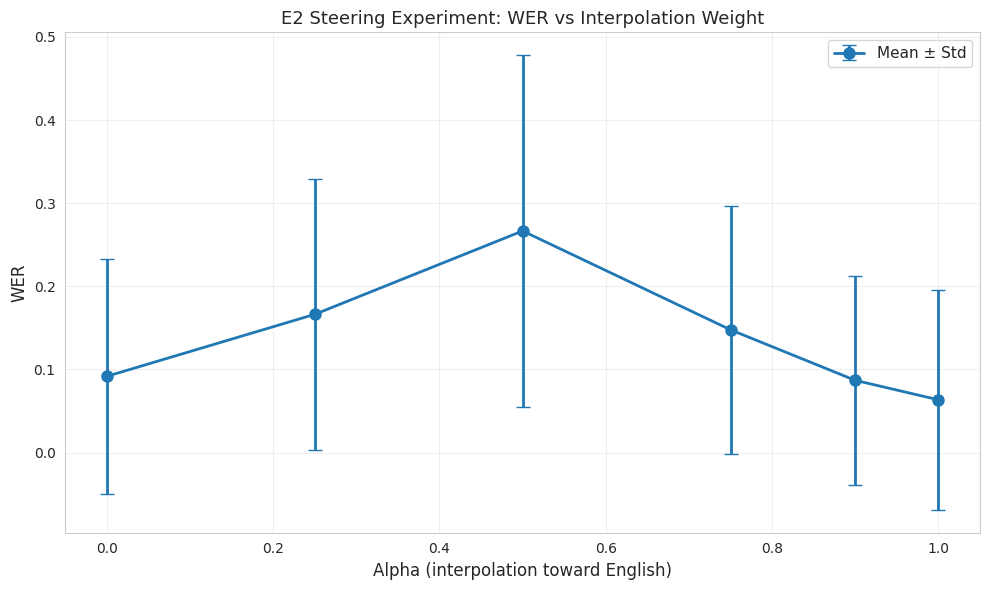

✓ Saved plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_wer_vs_alpha.png


In [36]:
# Visualize: WER vs alpha (overall)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean WER by alpha
alpha_stats = results_df.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'], 
            fmt='o-', linewidth=2, markersize=8, capsize=5, label='Mean ± Std')

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER', fontsize=12)
ax.set_title('E2 Steering Experiment: WER vs Interpolation Weight', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(output_dir / 'steering_wer_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved plot to {output_dir / 'steering_wer_vs_alpha.png'}")

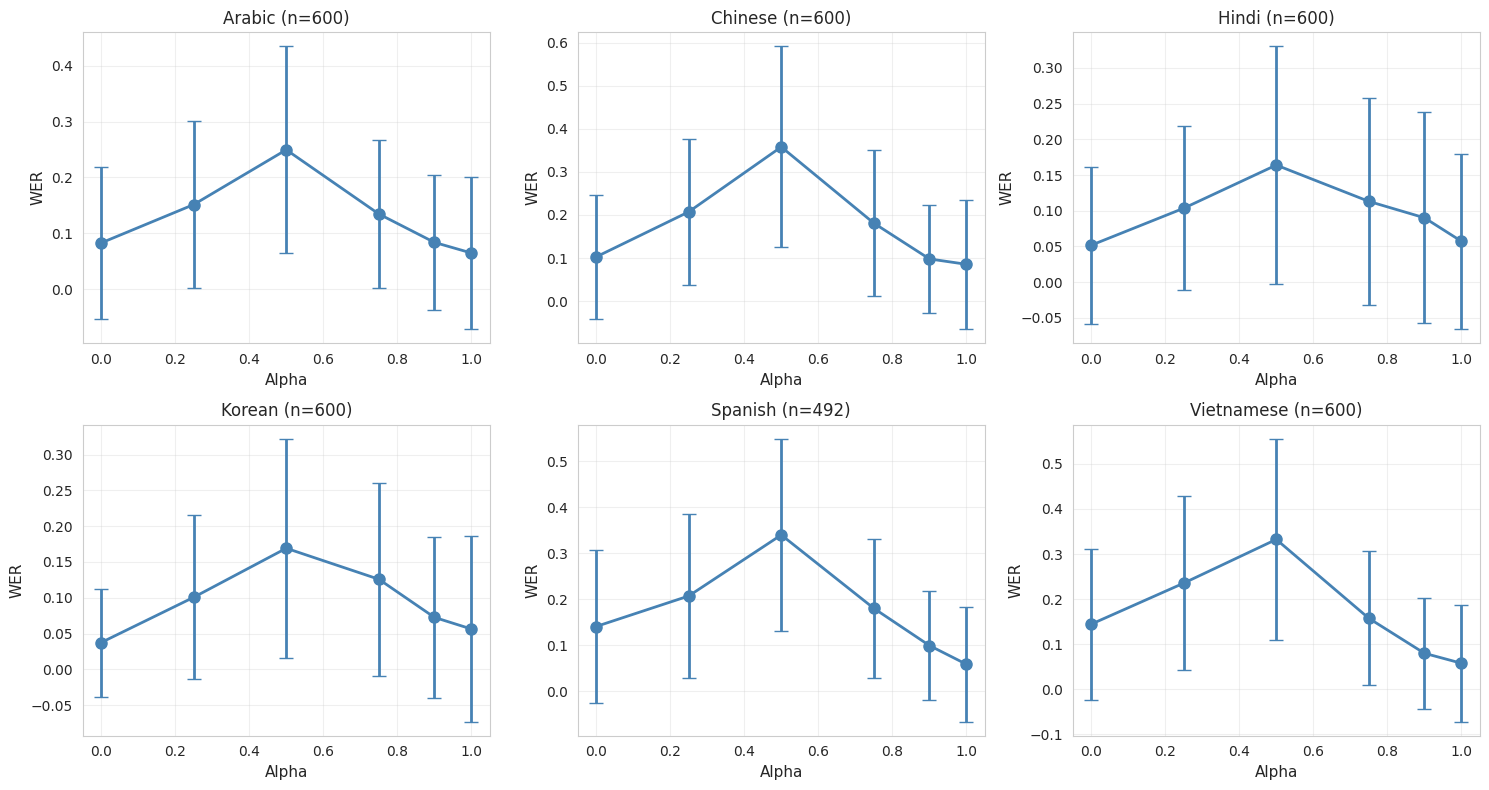

✓ Saved per-L1 plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_wer_per_l1.png


In [37]:
# Visualize: WER vs alpha per L1
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, l1 in enumerate(sorted(results_df['L1'].unique())):
    ax = axes[idx]
    subset = results_df[results_df['L1'] == l1]
    
    alpha_stats = subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
    ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                fmt='o-', linewidth=2, markersize=8, capsize=5, color='steelblue')
    
    ax.set_xlabel('Alpha', fontsize=11)
    ax.set_ylabel('WER', fontsize=11)
    ax.set_title(f'{l1} (n={len(subset)})', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'steering_wer_per_l1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved per-L1 plot to {output_dir / 'steering_wer_per_l1.png'}")

In [38]:
# ===== WARP L2 TO ENGLISH TIMELINE (DTW-BASED) =====
# DTW alignment but keep English intact; warp L2 onto English timeline

import time
from dtaidistance import dtw_ndim

def warp_l2_to_english_timeline(eng_state: np.ndarray, l2_state: np.ndarray, alpha: float) -> np.ndarray:
    """
    DTW-align then warp L2 onto English timeline (keep English intact).
    
    Args:
        eng_state: English encoder state, trimmed to speech (T_eng, 768)
        l2_state: L2 encoder state, trimmed to speech (T_l2, 768)
        alpha: Interpolation weight (0=pure L2, 1=pure English)
    
    Returns:
        Steered state on English timeline (T_eng, 768)
    """
    # Compute DTW warping path
    path = dtw_ndim.warping_path(eng_state, l2_state)
    path_array = np.array(path)
    
    # Accumulate L2 frames onto English time axis
    l2_aligned = np.zeros_like(eng_state)
    counts = np.zeros(len(eng_state))
    
    for i, j in path_array:
        l2_aligned[i] += l2_state[j]
        counts[i] += 1
    
    # Average where multiple L2 frames map to one English frame
    l2_aligned /= counts[:, None]
    
    # Interpolate: steered = α * eng + (1-α) * l2_aligned
    steered = alpha * eng_state + (1 - alpha) * l2_aligned
    
    return steered


def pad_to_1500_with_english(steered_state: np.ndarray, eng_state_full: np.ndarray, eng_speech_end: int) -> np.ndarray:
    """
    Pad steered state back to 1500 frames using English padding.
    
    Args:
        steered_state: Interpolated state on English timeline (T_eng, 768)
        eng_state_full: Full English state including padding (1500, 768)
        eng_speech_end: Frame index where English speech ends
    
    Returns:
        Padded state (1500, 768)
    """
    target_len = 1500
    steered_len = len(steered_state)
    
    if steered_len >= target_len:
        return steered_state[:target_len]
    
    # Use English padding for all interpolations
    eng_padding = eng_state_full[eng_speech_end:]
    padding_needed = target_len - steered_len
    
    if len(eng_padding) >= padding_needed:
        padding = eng_padding[:padding_needed]
    else:
        # Fallback: replicate last frame if not enough
        padding = eng_padding
        remaining = padding_needed - len(padding)
        if remaining > 0:
            padding = np.vstack([padding, np.tile(eng_padding[-1:], (remaining, 1))])
    
    padded = np.vstack([steered_state, padding])
    
    return padded.astype(np.float32)


print("✓ Warp-L2-to-English functions defined")

✓ Warp-L2-to-English functions defined


In [39]:
# Verify mapping has speech_end_frame; rebuild if needed
sample_prompt = list(mapping.keys())[0]
sample_l1_dict = mapping[sample_prompt]

has_speech_end_frame = any("speech_end_frame" in info for info in sample_l1_dict.values())

if not has_speech_end_frame:
    print("Rebuilding mapping with speech_end_frame info...")
    from src.utils.textgrid import parse_textgrid
    
    # Helper to parse CMU LAB files
    def parse_lab_file(lab_path: str):
        segments = []
        with open(lab_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        start_time = float(parts[0])
                        phone_label = parts[2]
                        if phone_label.lower() != 'pau':
                            segments.append((start_time, phone_label))
                    except (ValueError, IndexError):
                        continue
        
        if not segments:
            return None
        
        phone_segments = []
        for i, (start, label) in enumerate(segments):
            end = segments[i+1][0] if i+1 < len(segments) else start + 0.1
            phone_segments.append({'label': label.upper(), 'start': start, 'end': end})
        
        return phone_segments
    
    # Rebuild with speech_end_frame
    L2ARCTIC_ABS = ROOT / "data" / "l2_arctic"
    CMU_ARCTIC_ABS = ROOT / "data" / "cmu_arctic"
    
    for prompt_id in mapping.keys():
        l1_dict = mapping[prompt_id]
        for l1, info in l1_dict.items():
            if "speech_end_frame" in info:
                continue
            
            # Determine path based on L1
            if l1 == "English":
                speaker = info["speaker"]
                lab_path = CMU_ARCTIC_ABS / f"cmu_us_{speaker.lower()}_arctic" / "lab" / f"{prompt_id}.lab"
                if lab_path.exists():
                    try:
                        segments = parse_lab_file(str(lab_path))
                        if segments:
                            speech_end_frame = int(segments[-1]['end'] * 50) + 1
                            info["speech_end_frame"] = speech_end_frame
                    except Exception:
                        pass
            else:
                speaker = info["speaker"]
                tg_path = L2ARCTIC_ABS / speaker / "textgrid" / f"{prompt_id}.TextGrid"
                if tg_path.exists():
                    try:
                        segments = parse_textgrid(str(tg_path), tier_name='phones')
                        if segments:
                            speech_end_frame = int(segments[-1].end * 50) + 1
                            info["speech_end_frame"] = speech_end_frame
                    except Exception:
                        pass
    
    print("✓ Mapping rebuilt with speech_end_frame")
else:
    print("✓ Mapping already has speech_end_frame info")

# Check coverage
missing_count = sum(1 for l1d in mapping.values() for info in l1d.values() if "speech_end_frame" not in info)
print(f"  Entries with speech_end_frame: {sum(len(l1d) for l1d in mapping.values()) - missing_count}/{sum(len(l1d) for l1d in mapping.values())}")


✓ Mapping already has speech_end_frame info
  Entries with speech_end_frame: 682/682


In [40]:
# Run DTW-aligned steering experiment with L2 warped to English timeline (with caching)
alpha_values = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]
dtw_results_path = output_dir / "steering_results_dtw_aligned.csv"

# Check cache
if dtw_results_path.exists():
    print(f"Loading cached DTW-aligned results from {dtw_results_path}...")
    results_dtw_df = pd.read_csv(dtw_results_path)
    results_dtw = results_dtw_df.to_dict('records')
    print(f"✓ Loaded {len(results_dtw_df)} cached DTW results")
else:
    print("No DTW cache found. Running DTW-aligned steering experiment (L2 warped to English timeline)...")
    results_dtw = []

    prompts = sorted(mapping.keys())
    total_items = len(prompts) * 6 * len(alpha_values)
    
    with tqdm(total=total_items, desc="DTW Steering (L2→English)", unit="decode") as pbar:
        for prompt_idx, prompt_id in enumerate(prompts):
            l1_dict = mapping[prompt_id]

            # Skip if no English reference
            if "English" not in l1_dict:
                continue

            # Load English reference state
            eng_path = l1_dict["English"]["path"]
            eng_speech_end = l1_dict["English"].get("speech_end_frame")
            
            if not Path(eng_path).exists() or not eng_speech_end:
                pbar.update(6 * len(alpha_values))  # Skip all alphas for all L1s
                continue

            try:
                eng_state_full = load_checkpoint(eng_path)
                eng_state = eng_state_full[:eng_speech_end]  # Trim to speech
            except Exception as e:
                pbar.update(6 * len(alpha_values))
                continue

            # Test each L1 speaker
            for l1, speaker_info in l1_dict.items():
                if l1 == "English":
                    continue

                speaker = speaker_info["speaker"]
                l2_path = speaker_info["path"]
                l2_speech_end = speaker_info.get("speech_end_frame")

                if not Path(l2_path).exists() or not l2_speech_end:
                    pbar.update(len(alpha_values))
                    continue

                try:
                    l2_state_full = load_checkpoint(l2_path)
                    l2_state = l2_state_full[:l2_speech_end]  # Trim to speech
                except Exception as e:
                    pbar.update(len(alpha_values))
                    continue

                # Get reference text
                reference = ref_data.get((prompt_id, speaker))
                if reference is None:
                    pbar.update(len(alpha_values))
                    continue

                # Test each alpha value
                for alpha in alpha_values:
                    try:
                        # Warp L2 to English timeline and interpolate
                        steered_aligned = warp_l2_to_english_timeline(eng_state, l2_state, alpha)
                        
                        # Pad back to 1500 using English padding
                        steered_state = pad_to_1500_with_english(steered_aligned, eng_state_full, eng_speech_end)
                        
                        # Decode with steered state
                        steered_torch = torch.from_numpy(steered_state).to(device)
                        prediction = wrapper.decode(steered_torch)

                        # Compute WER
                        wer_score = jiwer.wer(norm(reference), norm(prediction))

                        results_dtw.append({
                            "prompt_id": prompt_id,
                            "L1": l1,
                            "speaker": speaker,
                            "alpha": alpha,
                            "wer": wer_score,
                            "method": "dtw_aligned",
                        })

                    except Exception as e:
                        pass
                    
                    pbar.update(1)

    print(f"✓ Computed DTW-aligned WER for {len(results_dtw)} utterances")
    
    # Save to cache
    results_dtw_df = pd.DataFrame(results_dtw)
    results_dtw_df.to_csv(dtw_results_path, index=False)
    print(f"✓ Saved DTW results to cache: {dtw_results_path}")

print(f"\nDTW results shape: {results_dtw_df.shape}")
print(f"Alpha values: {sorted(results_dtw_df['alpha'].unique())}")
print(f"L1s: {sorted(results_dtw_df['L1'].unique())}")
print(f"\nDTW WER stats:")
print(results_dtw_df.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

No DTW cache found. Running DTW-aligned steering experiment (L2 warped to English timeline)...


DTW Steering (L2→English):   0%|          | 0/3600 [00:00<?, ?decode/s]

✓ Computed DTW-aligned WER for 3492 utterances
✓ Saved DTW results to cache: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_results_dtw_aligned.csv

DTW results shape: (3492, 6)
Alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0)]
L1s: ['Arabic', 'Chinese', 'Hindi', 'Korean', 'Spanish', 'Vietnamese']

DTW WER stats:
         mean     std  min     max
alpha                             
0.00   0.1498  0.1638  0.0  0.8333
0.25   0.1015  0.1296  0.0  0.7273
0.50   0.0834  0.1228  0.0  0.6250
0.75   0.0728  0.1206  0.0  0.6250
0.90   0.0697  0.1310  0.0  0.7500
1.00   0.0660  0.1367  0.0  0.6250


In [41]:
print("="*70)
print("OVERALL WER by Alpha")
print("="*70)
print(results_dtw_df.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

print("\n\n\n")

print("="*70)
print("PER-L1 WER by Alpha")
print("="*70)
for l1 in sorted(results_dtw_df['L1'].unique()):
    l1_subset = results_dtw_df[results_dtw_df['L1'] == l1]
    print(f"\n{l1}:")
    print(l1_subset.groupby('alpha')['wer'].agg(['mean', 'std']).round(4))
print("✓ Updated cell 14 to print overall and per-L1 WER breakdowns by alpha")

OVERALL WER by Alpha
         mean     std  min     max
alpha                             
0.00   0.1498  0.1638  0.0  0.8333
0.25   0.1015  0.1296  0.0  0.7273
0.50   0.0834  0.1228  0.0  0.6250
0.75   0.0728  0.1206  0.0  0.6250
0.90   0.0697  0.1310  0.0  0.7500
1.00   0.0660  0.1367  0.0  0.6250




PER-L1 WER by Alpha

Arabic:
         mean     std
alpha                
0.00   0.1262  0.1336
0.25   0.0851  0.1068
0.50   0.0710  0.0929
0.75   0.0530  0.0947
0.90   0.0623  0.1214
1.00   0.0695  0.1426

Chinese:
         mean     std
alpha                
0.00   0.1660  0.1702
0.25   0.1192  0.1289
0.50   0.1078  0.1345
0.75   0.0875  0.1230
0.90   0.0822  0.1401
1.00   0.0759  0.1560

Hindi:
         mean     std
alpha                
0.00   0.0897  0.1173
0.25   0.0561  0.0943
0.50   0.0552  0.1090
0.75   0.0633  0.1188
0.90   0.0673  0.1300
1.00   0.0659  0.1330

Korean:
         mean     std
alpha                
0.00   0.1028  0.1325
0.25   0.0713  0.1248
0.50   0.0629  0.1256
0

In [42]:
# Compute WER delta (normalized improvement from L2 baseline) for all methods
print("Computing WER delta (normalized against L2 baseline per utterance)...\n")

# For each utterance, compute the L2 baseline WER (alpha=0.0)
def compute_wer_delta(results_df):
    """
    Compute WER_delta = WER_L2_baseline - WER_current for normalization.
    Positive delta means improvement from steering; negative means worse than L2.
    """
    # Get L2 baseline WER per utterance
    l2_baselines = results_df[results_df['alpha'] == 0.0][['prompt_id', 'L1', 'speaker', 'wer']].copy()
    l2_baselines.columns = ['prompt_id', 'L1', 'speaker', 'wer_l2_baseline']
    
    # Merge back to get delta for all alphas
    results_with_delta = results_df.merge(l2_baselines, on=['prompt_id', 'L1', 'speaker'], how='left')
    results_with_delta['wer_delta'] = results_with_delta['wer_l2_baseline'] - results_with_delta['wer']
    
    return results_with_delta

# Compute deltas
results_df_delta = compute_wer_delta(results_df)
results_dtw_df_delta = compute_wer_delta(results_dtw_df)

print(f"Position-based: WER delta stats")
print(results_df_delta.groupby('alpha')['wer_delta'].agg(['mean', 'std', 'min', 'max']).round(4))

print(f"\nDTW-aligned: WER delta stats")
print(results_dtw_df_delta.groupby('alpha')['wer_delta'].agg(['mean', 'std', 'min', 'max']).round(4))

print(f"\n✓ WER delta computed for all results")

Computing WER delta (normalized against L2 baseline per utterance)...

Position-based: WER delta stats
         mean     std     min     max
alpha                                
0.00   0.0000  0.0000  0.0000  0.0000
0.25  -0.0746  0.1535 -0.6667  0.5000
0.50  -0.1749  0.2241 -0.8333  0.6667
0.75  -0.0560  0.1830 -0.7500  0.8000
0.90   0.0048  0.1788 -0.6667  0.8000
1.00   0.0282  0.1809 -0.6250  0.8000

DTW-aligned: WER delta stats
         mean     std    min  max
alpha                            
0.00   0.0000  0.0000  0.000  0.0
0.25   0.0483  0.1170 -0.400  0.6
0.50   0.0664  0.1522 -0.500  0.8
0.75   0.0770  0.1642 -0.500  0.8
0.90   0.0801  0.1809 -0.500  0.8
1.00   0.0838  0.1908 -0.625  0.8

✓ WER delta computed for all results


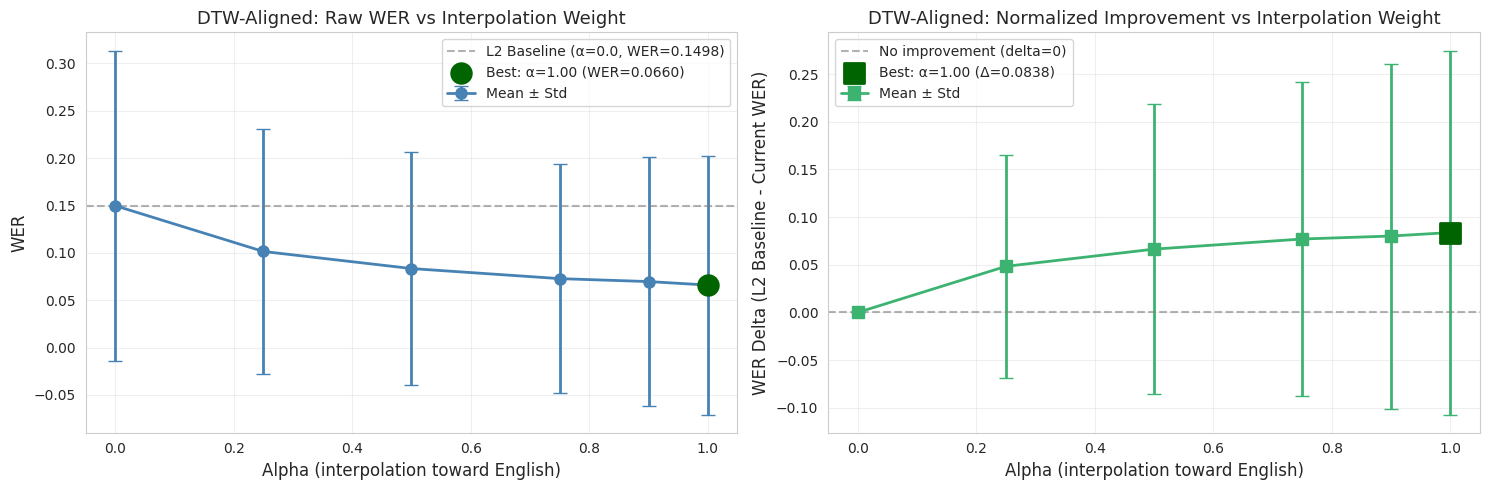

✓ Saved DTW raw WER + delta plots to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_dtw_raw_and_delta.png


In [43]:
# Visualize: DTW WER vs alpha (overall) with L2 baseline line + WER delta
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ===== RAW WER =====
ax = axes[0]
alpha_stats = results_dtw_df_delta.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
alpha_stats = alpha_stats.sort_values('alpha')
ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'], 
            fmt='o-', linewidth=2, markersize=8, capsize=5, label='Mean ± Std', color='steelblue')

# Add subtle horizontal line at L2 baseline
l2_baseline_wer = alpha_stats[alpha_stats['alpha'] == 0.0]['mean'].values[0]
ax.axhline(l2_baseline_wer, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label=f'L2 Baseline (α=0.0, WER={l2_baseline_wer:.4f})')

# Highlight best (lowest WER) point
best_idx = alpha_stats['mean'].idxmin()
best_alpha = alpha_stats.loc[best_idx, 'alpha']
best_wer = alpha_stats.loc[best_idx, 'mean']
ax.scatter([best_alpha], [best_wer], s=200, marker='o', color='darkgreen', 
           linewidth=2, edgecolor='darkgreen', zorder=5, label=f'Best: α={best_alpha:.2f} (WER={best_wer:.4f})')

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER', fontsize=12)
ax.set_title('DTW-Aligned: Raw WER vs Interpolation Weight', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# ===== WER DELTA =====
ax = axes[1]
delta_stats = results_dtw_df_delta.groupby('alpha')['wer_delta'].agg(['mean', 'std']).reset_index()
delta_stats = delta_stats.sort_values('alpha')
ax.errorbar(delta_stats['alpha'], delta_stats['mean'], yerr=delta_stats['std'], 
            fmt='s-', linewidth=2, markersize=8, capsize=5, label='Mean ± Std', color='mediumseagreen')

# Add zero line (no improvement)
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='No improvement (delta=0)')

# Highlight best (highest delta) point
best_delta_idx = delta_stats['mean'].idxmax()
best_delta_alpha = delta_stats.loc[best_delta_idx, 'alpha']
best_delta_val = delta_stats.loc[best_delta_idx, 'mean']
ax.scatter([best_delta_alpha], [best_delta_val], s=200, marker='s', color='darkgreen', 
           linewidth=2, edgecolor='darkgreen', zorder=5, label=f'Best: α={best_delta_alpha:.2f} (Δ={best_delta_val:.4f})')

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER Delta (L2 Baseline - Current WER)', fontsize=12)
ax.set_title('DTW-Aligned: Normalized Improvement vs Interpolation Weight', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / 'steering_dtw_raw_and_delta.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved DTW raw WER + delta plots to {output_dir / 'steering_dtw_raw_and_delta.png'}")

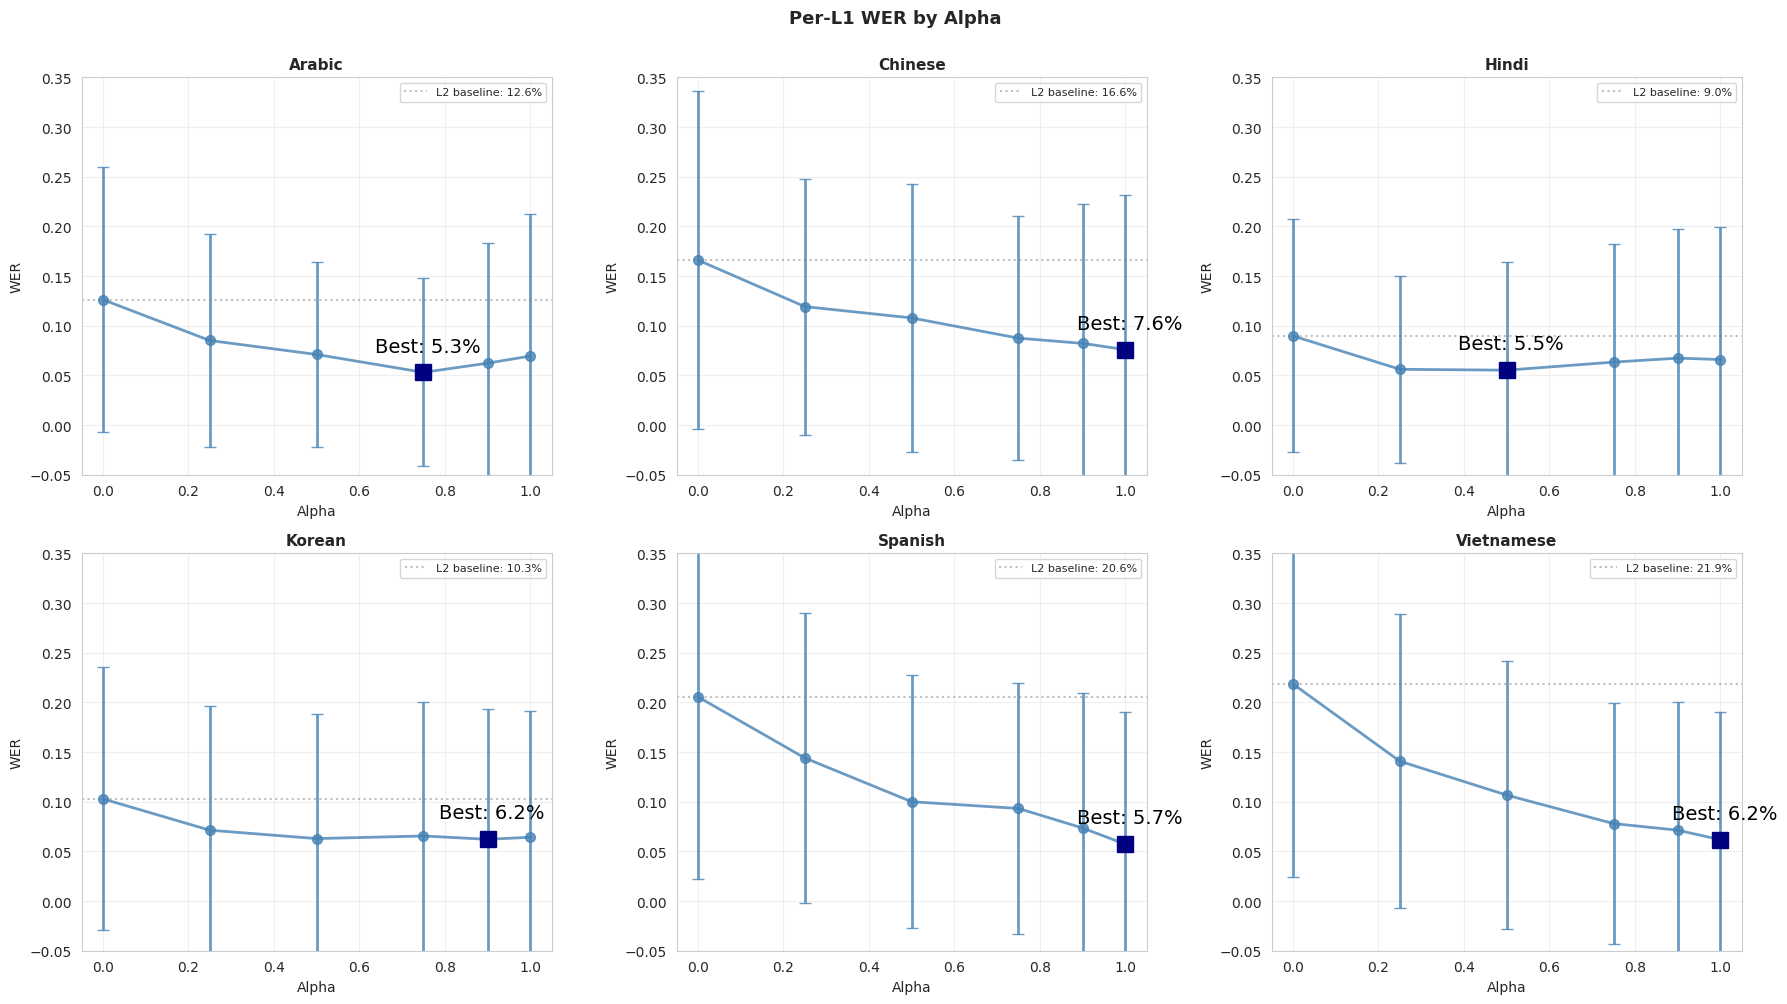

In [44]:
# Visualize: Per-L1 WER (raw) with baseline and best point labels
l1_list = sorted(results_dtw_df_delta['L1'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, l1 in enumerate(l1_list):
    ax = axes[idx]
    
    l1_subset = results_dtw_df_delta[results_dtw_df_delta['L1'] == l1]
    alpha_stats = l1_subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
    alpha_stats = alpha_stats.sort_values('alpha')
    
    ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                fmt='o-', linewidth=2, markersize=7, capsize=4, color='steelblue', alpha=0.8)
    
    # Get L2 baseline (alpha=0)
    l2_baseline_vals = alpha_stats[alpha_stats['alpha'] == 0.0]['mean'].values
    if len(l2_baseline_vals) > 0:
        l2_baseline = l2_baseline_vals[0]
        ax.axhline(l2_baseline, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label=f'L2 baseline: {l2_baseline:.1%}')
        ax.legend(fontsize=8, loc='best')
    
    # Mark best point (lowest WER)
    best_idx = alpha_stats['mean'].idxmin()
    best_alpha = alpha_stats.loc[best_idx, 'alpha']
    best_wer = alpha_stats.loc[best_idx, 'mean']
    ax.plot(best_alpha, best_wer, 's', color='navy', markersize=12, zorder=5)
    ax.annotate(f'Best: {best_wer:.1%}', xy=(best_alpha, best_wer), 
                xytext=(-35, 15), textcoords='offset points', fontsize=14, color='black')
    
    ax.set_xlabel('Alpha', fontsize=10)
    ax.set_ylabel('WER', fontsize=10)
    ax.set_ylim(-0.05, 0.35)
    ax.set_title(f'{l1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-L1 WER by Alpha', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(output_dir / 'per_l1_wer_raw.png', dpi=150, bbox_inches='tight')
plt.show()

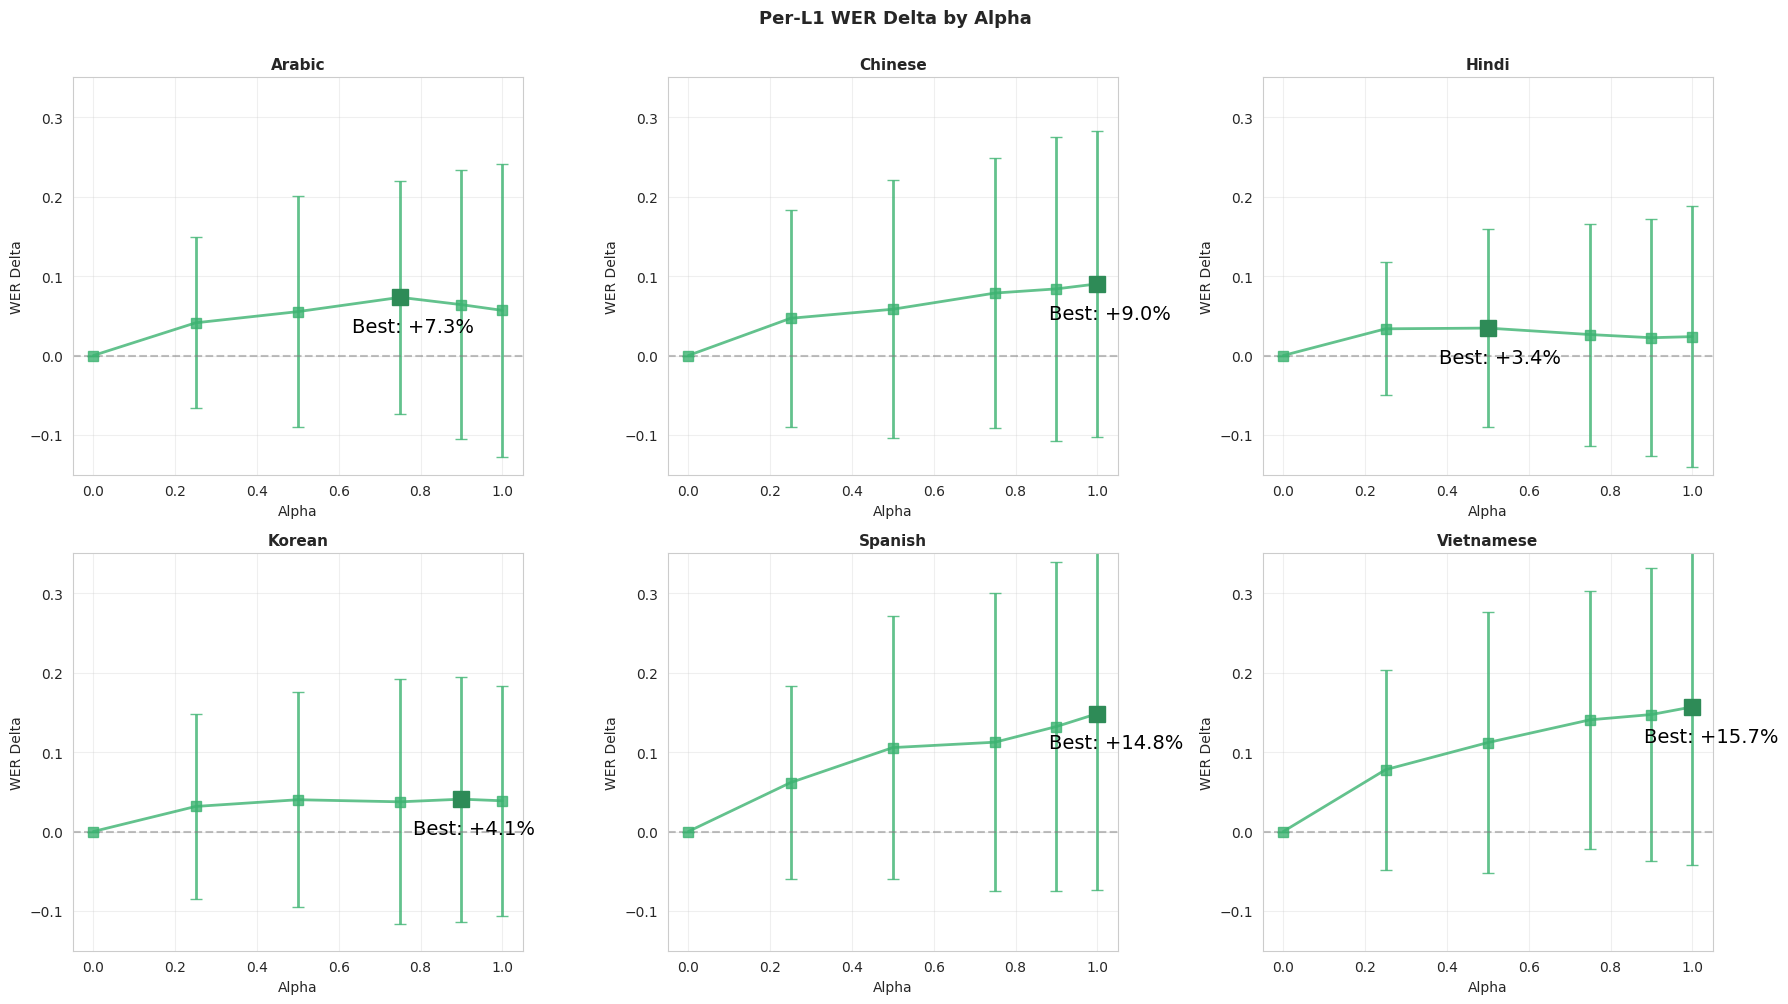

In [45]:
# Visualize: Per-L1 WER Delta (normalized) with best improvement label
l1_list = sorted(results_dtw_df_delta['L1'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, l1 in enumerate(l1_list):
    ax = axes[idx]
    
    l1_subset = results_dtw_df_delta[results_dtw_df_delta['L1'] == l1]
    delta_stats = l1_subset.groupby('alpha')['wer_delta'].agg(['mean', 'std']).reset_index()
    delta_stats = delta_stats.sort_values('alpha')
    
    ax.errorbar(delta_stats['alpha'], delta_stats['mean'], yerr=delta_stats['std'],
                fmt='s-', linewidth=2, markersize=7, capsize=4, color="mediumseagreen", alpha=0.8)
    
    # Zero line (no change)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    
    # Mark best improvement (most negative delta = best)
    best_idx = delta_stats['mean'].idxmax()
    best_alpha = delta_stats.loc[best_idx, 'alpha']
    best_delta = delta_stats.loc[best_idx, 'mean']
    ax.plot(best_alpha, best_delta, 's', color='seagreen', markersize=12, zorder=5)
    ax.annotate(f'Best: {best_delta:+.1%}', xy=(best_alpha, best_delta), 
                xytext=(-35, -25), textcoords='offset points', fontsize=14, color='black')
    
    ax.set_xlabel('Alpha', fontsize=10)
    ax.set_ylabel('WER Delta', fontsize=10)
    ax.set_ylim(-0.15, 0.35)
    ax.set_title(f'{l1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-L1 WER Delta by Alpha', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(output_dir / 'per_l1_wer_delta.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Combine position-based and DTW-aligned results
# Add method column to both dataframes
results_df_with_method = results_df.copy()
results_df_with_method['method'] = 'position_based'

results_dtw_df_with_method = results_dtw_df.copy()
results_dtw_df_with_method['method'] = 'dtw_aligned'

# Combine
results_combined_df = pd.concat([results_df_with_method, results_dtw_df_with_method], ignore_index=True)

# Save combined results
combined_results_path = output_dir / "steering_results_combined.csv"
results_combined_df.to_csv(combined_results_path, index=False)
print(f"✓ Saved {len(results_combined_df)} combined results to {combined_results_path}")

print(f"\nCombined results shape: {results_combined_df.shape}")
print(f"Methods: {sorted(results_combined_df['method'].unique())}")
print(f"Position-based: {len(results_combined_df[results_combined_df['method'] == 'position_based'])}")
print(f"DTW-aligned: {len(results_combined_df[results_combined_df['method'] == 'dtw_aligned'])}")

print(f"\nWER stats by method:")
for method in sorted(results_combined_df['method'].unique()):
    subset = results_combined_df[results_combined_df['method'] == method]
    print(f"\n{method}:")
    print(subset.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

✓ Saved 6984 combined results to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_results_combined.csv

Combined results shape: (6984, 6)
Methods: ['dtw_aligned', 'position_based']
Position-based: 3492
DTW-aligned: 3492

WER stats by method:

dtw_aligned:
         mean     std  min     max
alpha                             
0.00   0.1498  0.1638  0.0  0.8333
0.25   0.1015  0.1296  0.0  0.7273
0.50   0.0834  0.1228  0.0  0.6250
0.75   0.0728  0.1206  0.0  0.6250
0.90   0.0697  0.1310  0.0  0.7500
1.00   0.0660  0.1367  0.0  0.6250

position_based:
         mean     std  min     max
alpha                             
0.00   0.0918  0.1414  0.0  0.8000
0.25   0.1663  0.1633  0.0  0.8333
0.50   0.2667  0.2115  0.0  0.8571
0.75   0.1477  0.1493  0.0  0.7500
0.90   0.0869  0.1254  0.0  0.6667
1.00   0.0635  0.1325  0.0  0.6250



dtw_aligned alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0)]
WER at each alpha:
   alpha      mean       std
0   0.00  0.149813  0.163799
1   0.25  0.101478  0.129580
2   0.50  0.083428  0.122841
3   0.75  0.072806  0.120629
4   0.90  0.069688  0.130992
5   1.00  0.066012  0.136689

position_based alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0)]
WER at each alpha:
   alpha      mean       std
0   0.00  0.091776  0.141359
1   0.25  0.166332  0.163315
2   0.50  0.266652  0.211549
3   0.75  0.147741  0.149302
4   0.90  0.086934  0.125355
5   1.00  0.063527  0.132524


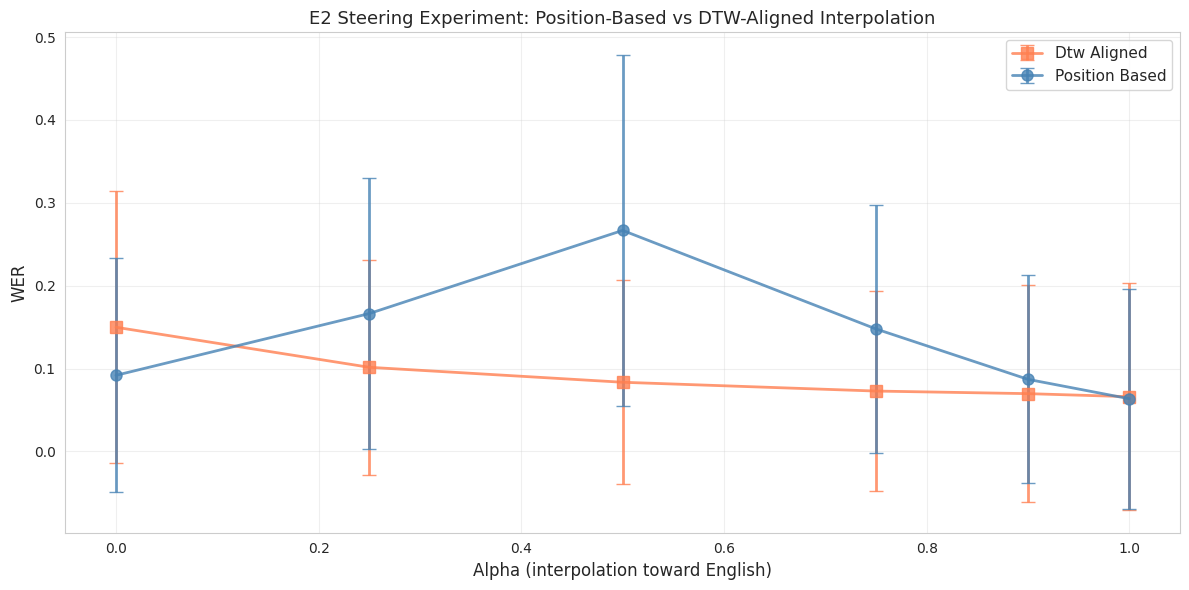


✓ Saved comparison plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_wer_comparison.png


In [47]:
# Visualize: WER vs alpha comparison (position-based vs DTW-aligned)
# Ensure alpha is numeric
results_combined_df['alpha'] = pd.to_numeric(results_combined_df['alpha'])

fig, ax = plt.subplots(figsize=(12, 6))

methods = sorted(results_combined_df['method'].unique())
colors = {'position_based': 'steelblue', 'dtw_aligned': 'coral'}
markers = {'position_based': 'o', 'dtw_aligned': 's'}

for method in methods:
    subset = results_combined_df[results_combined_df['method'] == method]
    alpha_stats = subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
    alpha_stats = alpha_stats.sort_values('alpha')  # Ensure sorted by alpha
    
    print(f"\n{method} alpha values: {sorted(alpha_stats['alpha'].unique())}")
    print(f"WER at each alpha:\n{alpha_stats}")
    
    ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                fmt=markers[method] + '-', linewidth=2, markersize=8, capsize=5,
                label=method.replace('_', ' ').title(), color=colors[method], alpha=0.8)

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER', fontsize=12)
ax.set_title('E2 Steering Experiment: Position-Based vs DTW-Aligned Interpolation', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig(output_dir / 'steering_wer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved comparison plot to {output_dir / 'steering_wer_comparison.png'}")

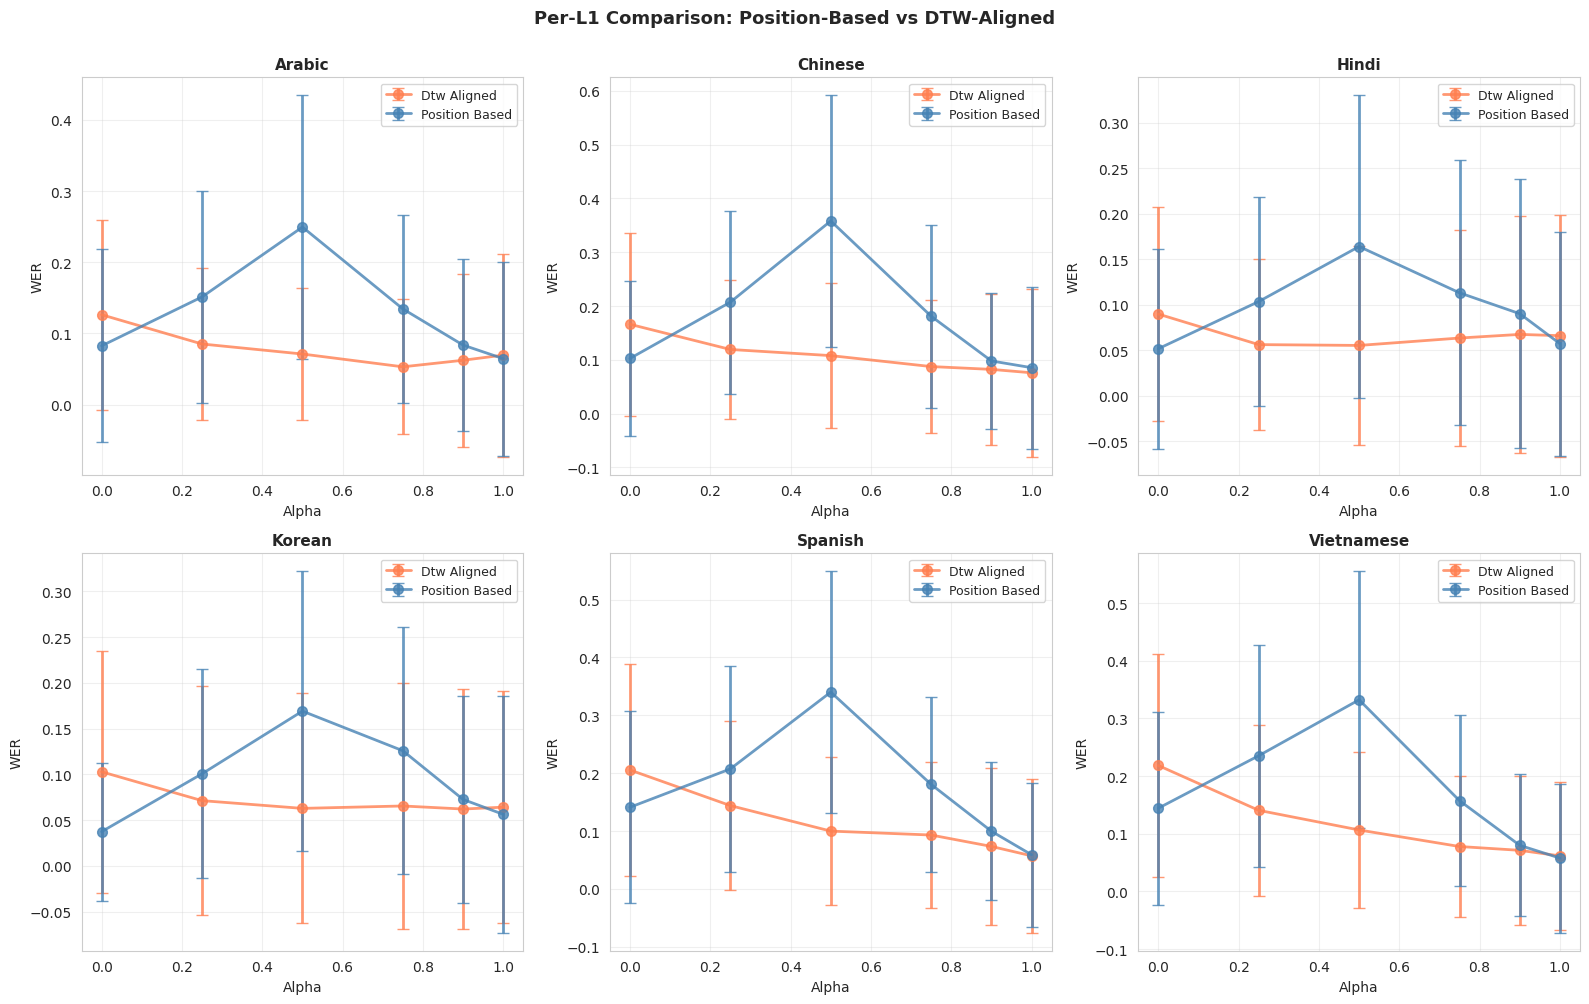

✓ Saved per-L1 comparison plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_per_l1_comparison.png


In [48]:
# Visualize: Per-L1 comparison
# Ensure alpha is numeric
results_combined_df['alpha'] = pd.to_numeric(results_combined_df['alpha'])

l1_list = sorted(results_combined_df['L1'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

methods = sorted(results_combined_df['method'].unique())
colors = {'position_based': 'steelblue', 'dtw_aligned': 'coral'}

for idx, l1 in enumerate(l1_list):
    ax = axes[idx]
    
    for method in methods:
        subset = results_combined_df[(results_combined_df['L1'] == l1) & (results_combined_df['method'] == method)]
        alpha_stats = subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
        alpha_stats = alpha_stats.sort_values('alpha')  # Ensure sorted by alpha
        
        ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                    fmt='o-', linewidth=2, markersize=7, capsize=4, label=method.replace('_', ' ').title(),
                    color=colors[method], alpha=0.8)
    
    ax.set_xlabel('Alpha', fontsize=10)
    ax.set_ylabel('WER', fontsize=10)
    ax.set_title(f'{l1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Per-L1 Comparison: Position-Based vs DTW-Aligned', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(output_dir / 'steering_per_l1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved per-L1 comparison plot to {output_dir / 'steering_per_l1_comparison.png'}")

In [49]:
# Summary statistics
print("\n" + "="*70)
print("E2 LATENT STEERING EXPERIMENT - SUMMARY")
print("="*70)

baseline_wer = results_df[results_df['alpha'] == 0.0]['wer'].mean()
oracle_wer = results_df[results_df['alpha'] == 1.0]['wer'].mean()
improvement = (baseline_wer - oracle_wer) / baseline_wer * 100

print(f"\nBaseline (α=0.0, pure L2): {baseline_wer:.4f}")
print(f"Oracle (α=1.0, pure English): {oracle_wer:.4f}")
print(f"Improvement: {improvement:.1f}% WER reduction")

print(f"\nPer-L1 WER at α=0.0 vs α=1.0:")
for l1 in sorted(results_df['L1'].unique()):
    subset = results_df[results_df['L1'] == l1]
    baseline = subset[subset['alpha'] == 0.0]['wer'].mean()
    oracle = subset[subset['alpha'] == 1.0]['wer'].mean()
    delta = baseline - oracle
    pct = delta / baseline * 100 if baseline > 0 else 0
    print(f"  {l1:15s}: {baseline:.4f} → {oracle:.4f} (Δ={delta:+.4f}, {pct:+.1f}%)")

print("\n" + "="*70)


E2 LATENT STEERING EXPERIMENT - SUMMARY

Baseline (α=0.0, pure L2): 0.0918
Oracle (α=1.0, pure English): 0.0635
Improvement: 30.8% WER reduction

Per-L1 WER at α=0.0 vs α=1.0:
  Arabic         : 0.0825 → 0.0645 (Δ=+0.0180, +21.8%)
  Chinese        : 0.1025 → 0.0854 (Δ=+0.0171, +16.7%)
  Hindi          : 0.0516 → 0.0571 (Δ=-0.0056, -10.8%)
  Korean         : 0.0374 → 0.0563 (Δ=-0.0189, -50.6%)
  Spanish        : 0.1411 → 0.0591 (Δ=+0.0820, +58.1%)
  Vietnamese     : 0.1444 → 0.0579 (Δ=+0.0865, +59.9%)



In [51]:
# Find missing utterances
pos_based_keys = set(zip(results_df['prompt_id'],
results_df['speaker']))
dtw_keys = set(zip(results_dtw_df['prompt_id'],
results_dtw_df['speaker']))

missing_in_dtw = pos_based_keys - dtw_keys
extra_in_pos = dtw_keys - pos_based_keys

print(f"Utterances in position-based but NOT in DTW (found {len(missing_in_dtw)}): {missing_in_dtw}")
print(f"Utterances in DTW but NOT in position-based (found {len(extra_in_pos)}): {extra_in_pos}")

if missing_in_dtw:
      print(f"\nWER of missing utterance in position-based:")
      for prompt_id, speaker in missing_in_dtw:
            wer_val = results_df[(results_df['prompt_id']==prompt_id)
      & (results_df['speaker']==speaker) &
      (results_df['alpha']==1.0)]['wer'].values
            if len(wer_val) > 0:
                  print(f"  {prompt_id}/{speaker}: {wer_val[0]:.4f}")

Utterances in position-based but NOT in DTW (found 0): set()
Utterances in DTW but NOT in position-based (found 0): set()
